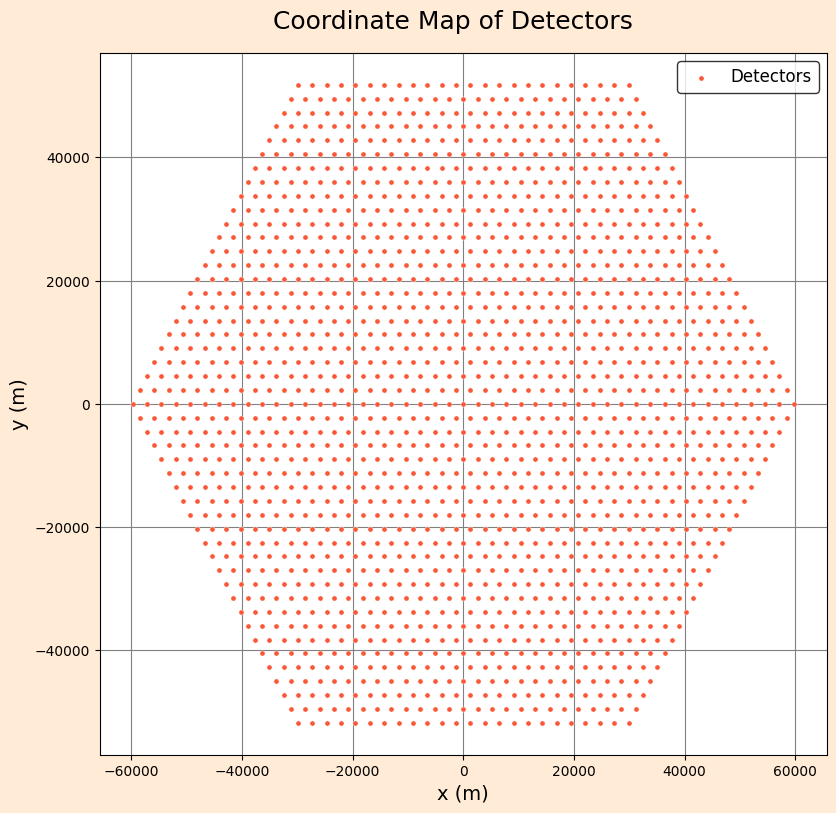

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Parâmetros do grid
grid_radius = 23  # Raio do grid em número de camadas
hex_size = 1500  # Tamanho do lado do hexágono

def create_hexagonal_grid():
    positions = []
    dx = hex_size * np.sqrt(3)  
    dy = 1.5 * hex_size         

    for q in range(-grid_radius, grid_radius + 1):
        for r in range(-grid_radius, grid_radius + 1):
            s = -q - r
            if abs(s) <= grid_radius:
                x = hex_size * np.sqrt(3) * (q + r / 2.0)
                y = dy * r
                positions.append((x, y))
    return positions

# Criar o grid
positions = create_hexagonal_grid()
x_positions, y_positions = zip(*positions)


# Configuração do gráfico
fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='#FFEBD6')
fig.suptitle('Coordinate Map of Detectors', size=18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

# Plota os detectores
sns.scatterplot(
    x=x_positions,
    y=y_positions,
    ax=ax,
    color='#F95738',
    s=14,
    #edgecolor="black"
)

ax.set_xlabel('x (m)', size=14)
ax.set_ylabel('y (m)', size=14)

# Configurações da legenda
ax.legend(['Detectors'], edgecolor='black', fontsize=12, loc=1)

plt.show()


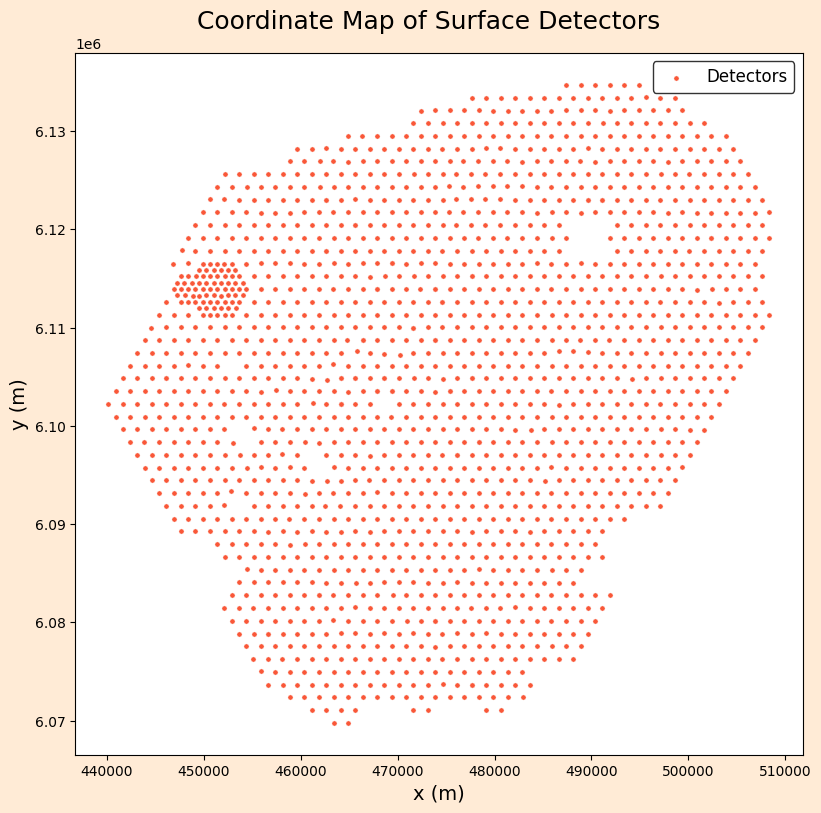

In [2]:
sdmap = pd.read_csv("sdMap.csv")

# Configuração do gráfico
fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='#FFEBD6')
fig.suptitle('Coordinate Map of Surface Detectors', size=18)
fig.tight_layout()
ax.set_axisbelow(True)
#ax.yaxis.grid(color='gray', linestyle='-')
#ax.xaxis.grid(color='gray', linestyle='-')

# Plota os detectores
sns.scatterplot(
    x=sdmap['easting'],
    y=sdmap['northing'],
    ax=ax,
    color='#F95738',
    s=14,
    #edgecolor="black"
)

ax.set_xlabel('x (m)', size=14)
ax.set_ylabel('y (m)', size=14)

# Configurações da legenda
ax.legend(['Detectors'], edgecolor='black', fontsize=12, loc=1)

plt.show()

In [3]:
df_stop = sdmap[sdmap['stop'] != 1]
df_stop.shape

(53, 8)

In [4]:
sdmap.shape

(1689, 8)

In [5]:
1689-53

1636

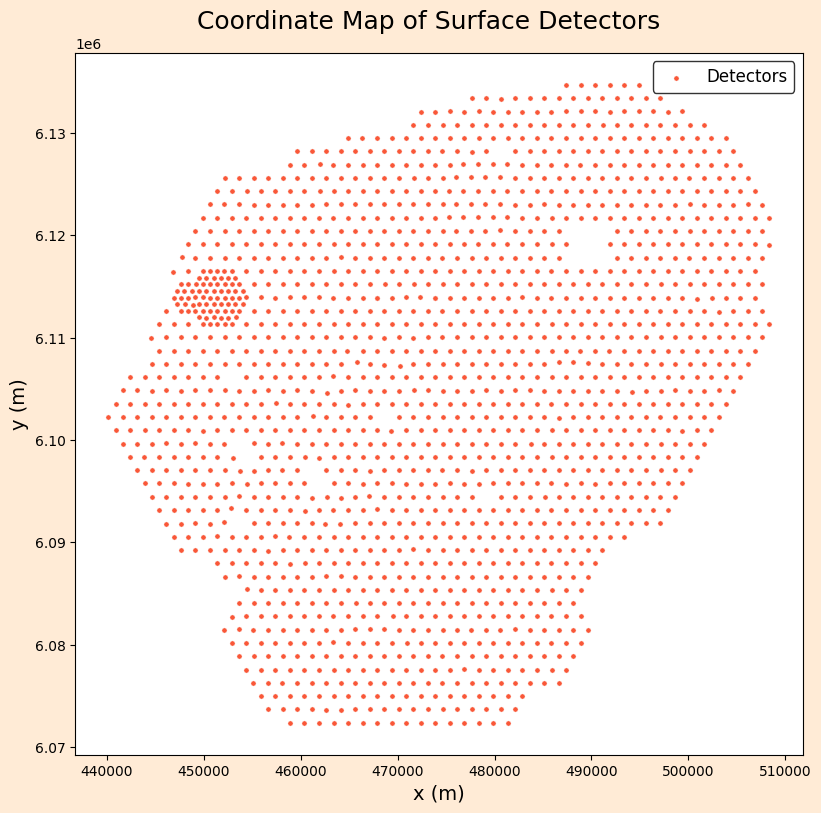

In [6]:
sdmap1 = sdmap[sdmap['stop'] == 1]

# Configuração do gráfico
fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='#FFEBD6')
fig.suptitle('Coordinate Map of Surface Detectors', size=18)
fig.tight_layout()
ax.set_axisbelow(True)
#ax.yaxis.grid(color='gray', linestyle='-')
#ax.xaxis.grid(color='gray', linestyle='-')

# Plota os detectores
sns.scatterplot(
    x=sdmap1['easting'],
    y=sdmap1['northing'],
    ax=ax,
    color='#F95738',
    s=14,
    #edgecolor="black"
)

ax.set_xlabel('x (m)', size=14)
ax.set_ylabel('y (m)', size=14)

# Configurações da legenda
ax.legend(['Detectors'], edgecolor='black', fontsize=12, loc=1)

plt.show()

In [ ]:
# Média das coordenadas para encontrar o ponto de origem
mean_northing = sdmap1['northing'].mean()
mean_easting = sdmap1['easting'].mean()

# Identificar a estação mais próxima do centro
distances = np.sqrt((sdmap1['northing'] - mean_northing)**2 + (sdmap1['easting'] - mean_easting)**2)
closest_station_index = distances.idxmin()

# Coordenadas da estação central
origin_northing = sdmap1.loc[closest_station_index, 'northing']
origin_easting = sdmap1.loc[closest_station_index, 'easting']

# Calcular as coordenadas cartesianas relativas à origem
sdmap1.loc[:, 'x'] = sdmap1['easting'] - origin_easting
sdmap1.loc[:, 'y'] = sdmap1['northing'] - origin_northing

#output_file = 'estacoes_cartesianas.csv'
#sdmap1.to_csv(output_file, index=False)

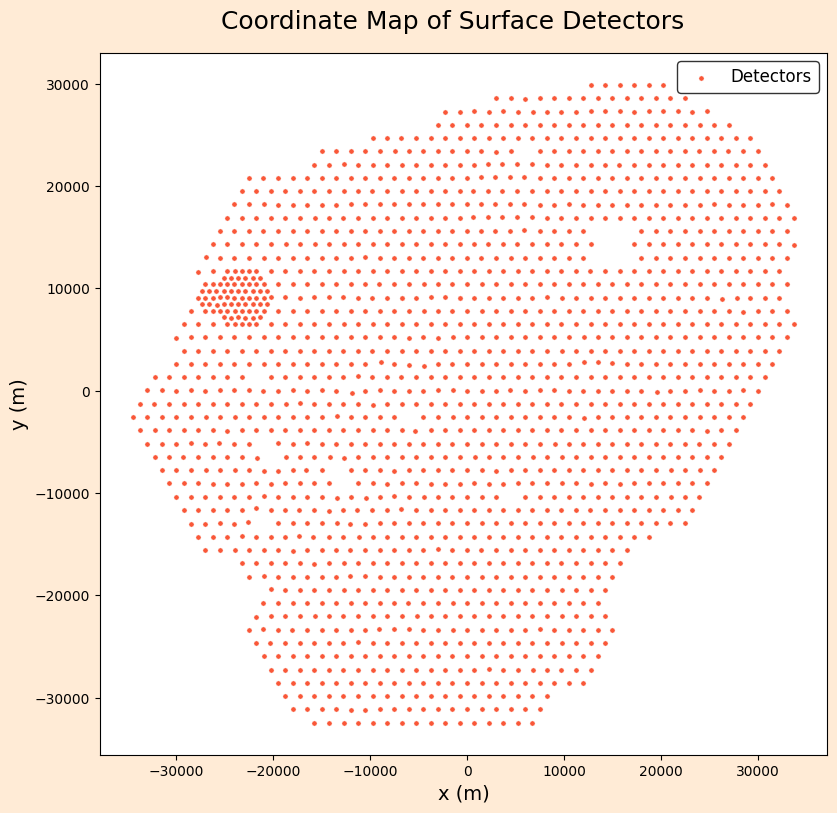

In [15]:
# Configuração do gráfico
fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='#FFEBD6')
fig.suptitle('Coordinate Map of Surface Detectors', size=18)
fig.tight_layout()
ax.set_axisbelow(True)
#ax.yaxis.grid(color='gray', linestyle='-')
#ax.xaxis.grid(color='gray', linestyle='-')

# Plota os detectores
sns.scatterplot(
    x=sdmap1['x'],
    y=sdmap1['y'],
    ax=ax,
    color='#F95738',
    s=14,
    #edgecolor="black"
)

ax.set_xlabel('x (m)', size=14)
ax.set_ylabel('y (m)', size=14)

# Configurações da legenda
ax.legend(['Detectors'], edgecolor='black', fontsize=12, loc=1)

plt.show()

In [16]:
sdmap1[sdmap1['x'] == 0]

,id,northing,easting,altitude,start,stop,sd1500,sd750,x,y
726,838,6104816.14,474636.9,1402.19,829008000,1,1,0,0.0,0.0


In [17]:
sdmap1

,id,northing,easting,altitude,start,stop,sd1500,sd750,x,y
0,101,6091837.98,468619.84,1403.75,741657600,1,1,0,-6017.06,-12978.16
1,102,6089249.42,468626.01,1401.50,742348800,1,1,0,-6010.89,-15566.72
2,103,6091856.57,467127.23,1406.90,742348800,1,1,0,-7509.67,-12959.57
3,104,6093214.94,467823.99,1407.66,743299200,1,1,0,-6812.91,-11601.20
4,105,6089277.69,470118.65,1399.31,741830400,1,1,0,-4518.25,-15538.45
...,...,...,...,...,...,...,...,...,...,...
1684,1841,6111975.35,449498.84,1566.95,999605110,1,0,1,-25138.06,7159.21
1685,1842,6111315.38,450627.78,1555.88,998863567,1,0,1,-24009.12,6499.24
1686,1843,6111322.00,452123.72,1544.15,998877162,1,0,1,-22513.18,6505.86
1687,1844,6111962.67,450252.44,1562.08,999533712,1,0,1,-24384.46,7146.53
